# Cuantificacion de incerteza con redes neuronales en PyTorch y Bayesian-Torch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana07_UQ.ipynb)

En esta notebook vamos a estudiar distintas estrategias para cuantificar incerteza predictiva en un problema de regresion tabular.

El objetivo sera predecir la **temperatura aparente** (`apparent_temperature`) a partir de variables meteorologicas como:

- temperatura medida;
- humedad;
- velocidad del viento;
- direccion del viento;
- visibilidad;
- presion.

Dentro de esta notebook veremos:

- una red **deterministica** como baseline;
- **deep ensembles**;
- **Monte Carlo dropout**;
- una **Bayesian Neural Network** con `bayesian-torch`;
- una **BNN probabilistica**, que ademas modele incertidumbre aleatorica en la salida.

Objetivos de aprendizaje:

- ver que informacion aporta un modelo puntual y que informacion falta;
- comparar tres aproximaciones practicas a la incertidumbre epistemica;
- entender el rol del termino `KL` en una BNN;
- separar, al menos de manera aproximada, la parte epistemica y la aleatorica en una red probabilistica.


## Librerias necesarias

Esta notebook usa `torch`, `pandas`, `matplotlib` y `bayesian-torch`.

Si hace falta, se pueden instalar asi:

```python
# !pip install torch torchvision torchaudio
# !pip install pandas matplotlib bayesian-torch
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from bayesian_torch.layers import LinearReparameterization

SEED = 42


def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
print("Torch:", torch.__version__)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


Dispositivo: cpu
Torch: 2.5.1


## Parte 1

### El problema y el dataset

La temperatura aparente combina la temperatura ambiente con otros factores que afectan la sensacion termica, especialmente el viento y la humedad.

Desde el punto de vista de modelado, esto es un problema de regresion con varias entradas numericas y una salida continua. Es un buen escenario para comparar metodos de cuantificacion de incerteza porque:

- la regresion es sencilla de entrenar;
- hay suficientes datos para que el baseline funcione razonablemente bien;
- aun asi, distintos metodos pueden dar niveles de confianza distintos.


In [2]:
def compute_standardization_stats(tensor):
    mean = tensor.mean(dim=0, keepdim=True)
    std = tensor.std(dim=0, unbiased=False, keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return mean, std


def standardize(tensor, mean, std):
    return (tensor - mean) / std


def destandardize(tensor, mean, std):
    return tensor * std + mean


def inverse_transform_targets(values, y_mean, y_std):
    values = np.asarray(values, dtype=np.float32).reshape(-1, 1)
    restored = values * y_std.cpu().numpy() + y_mean.cpu().numpy()
    return restored.reshape(-1)


def get_weather_dataloaders(
    train_size: float,
    batch_size: int,
    seed: int = 0,
    num_workers: int = 0,
    pin_memory: bool = True,
    dataset_size: float = 1.0,
):
    if not (0.0 < train_size <= 1.0):
        raise ValueError(f"train_size must be in (0, 1], got {train_size}")

    url = "https://raw.githubusercontent.com/pandego/mdn-playground/refs/heads/main/data/01_raw/weather_dataset/weather_dataset_example.csv"
    df = pd.read_csv(url, delimiter=";")

    if dataset_size < 1.0:
        n_samples = int(len(df) * dataset_size)
        df = df.sample(n=n_samples, random_state=seed).reset_index(drop=True)

    target_col = "apparent_temperature"
    feature_cols = [c for c in df.columns if c != target_col]

    X = torch.tensor(df[feature_cols].to_numpy(dtype=np.float32))
    y = torch.tensor(df[[target_col]].to_numpy(dtype=np.float32))

    num_samples = X.shape[0]
    rng = np.random.default_rng(seed)
    perm = torch.tensor(rng.permutation(num_samples), dtype=torch.long)

    n_train = int(train_size * num_samples)
    if n_train == 0 or n_train == num_samples:
        raise ValueError("El split train/test quedo degenerado.")

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    X_train_raw = X[train_idx]
    y_train_raw = y[train_idx]
    X_test_raw = X[test_idx]
    y_test_raw = y[test_idx]

    x_mean, x_std = compute_standardization_stats(X_train_raw)
    y_mean, y_std = compute_standardization_stats(y_train_raw)

    X_train = standardize(X_train_raw, x_mean, x_std)
    X_test = standardize(X_test_raw, x_mean, x_std)
    y_train = standardize(y_train_raw, y_mean, y_std)
    y_test = standardize(y_test_raw, y_mean, y_std)

    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return {
        "df": df,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "X_train_raw": X_train_raw,
        "y_train_raw": y_train_raw,
        "X_test_raw": X_test_raw,
        "y_test_raw": y_test_raw,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
    }


TRAIN_SIZE = 0.70
BATCH_SIZE = 512

weather = get_weather_dataloaders(
    train_size=TRAIN_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

df = weather["df"]
FEATURE_NAMES = weather["feature_cols"]
TARGET_COL = weather["target_col"]
NUM_FEATURES = len(FEATURE_NAMES)
train_dataloader = weather["train_loader"]
test_dataloader = weather["test_loader"]

print("Cantidad total de muestras:", len(df))
print("Tamaño train:", len(train_dataloader.dataset))
print("Tamaño test:", len(test_dataloader.dataset))
df.head()


Cantidad total de muestras: 96453
Tamaño train: 67517
Tamaño test: 28936


,temperature,apparent_temperature,humidity,wind_speed,wind_bearing,visibility,pressure
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


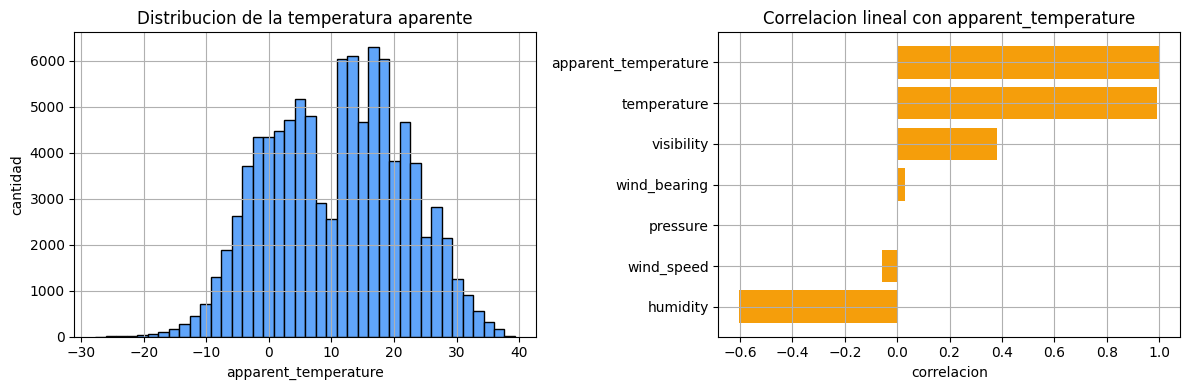

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET_COL], bins=40, color="#60a5fa", edgecolor="black")
axes[0].set_title("Distribucion de la temperatura aparente")
axes[0].set_xlabel("apparent_temperature")
axes[0].set_ylabel("cantidad")

corr = df.corr(numeric_only=True)[TARGET_COL].sort_values()
axes[1].barh(corr.index, corr.values, color="#f59e0b")
axes[1].set_title("Correlacion lineal con apparent_temperature")
axes[1].set_xlabel("correlacion")

plt.tight_layout()
plt.show()


Tomaremos una muestra fija del conjunto de test para comparar todos los metodos sobre exactamente los mismos casos.


In [4]:
sample_size = 50

example_inputs = weather["X_test"][:sample_size]
example_targets_std = weather["y_test"][:sample_size].squeeze(-1).cpu().numpy()
example_targets = inverse_transform_targets(
    example_targets_std,
    weather["y_mean"],
    weather["y_std"],
)
example_inputs_raw = weather["X_test_raw"][:sample_size].cpu().numpy()

pd.DataFrame(example_inputs_raw, columns=FEATURE_NAMES).assign(
    apparent_temperature=example_targets
).round(3)


,temperature,humidity,wind_speed,wind_bearing,visibility,pressure,apparent_temperature
0,-5.528000,0.85,6.360000,166.0,6.617,1043.619995,-8.522000
1,2.800000,0.75,12.526000,129.0,11.270,1018.169983,-0.500000
2,6.078000,0.87,12.284000,17.0,11.190,1021.989990,3.528000
3,3.333000,0.73,14.490000,300.0,16.100,1018.900024,-0.206000
4,10.000000,0.34,8.050000,220.0,9.982,1010.299988,9.011000
5,5.044000,0.93,1.626000,148.0,7.728,1031.479980,5.044000
6,-2.811000,0.99,13.926000,288.0,6.456,1018.250000,-7.633000
7,26.156000,0.41,14.152000,10.0,16.100,1022.429993,26.156000
8,16.183001,0.52,8.018000,13.0,15.826,1017.320007,16.183001
9,-0.050000,1.00,1.288000,76.0,0.161,1011.280029,-0.050000


## Parte 2

### Baseline determinista

Empezamos con una MLP comun. Esta red aprende una sola prediccion puntual para cada entrada.

Eso sirve como baseline, pero no alcanza para responder una pregunta importante: **cuan confiado esta el modelo** en cada prediccion?


In [5]:
hidden_units = [32, 32]


class MLP(nn.Module):
    def __init__(self, dropout_rate=0.0, hidden_units=(32, 32), activation="relu"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU
        elif activation == "sigmoid":
            act = nn.Sigmoid
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'.")

        layers = [nn.BatchNorm1d(NUM_FEATURES)]
        input_dim = NUM_FEATURES
        for units in hidden_units:
            layers.append(nn.Linear(input_dim, units))
            layers.append(act())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            input_dim = units
        layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def rmse_in_original_units(pred_std, target_std):
    pred = inverse_transform_targets(pred_std, weather["y_mean"], weather["y_std"])
    target = inverse_transform_targets(target_std, weather["y_mean"], weather["y_std"])
    return float(np.sqrt(np.mean((pred - target) ** 2)))


def evaluate_point_model(model, dataloader, device=DEVICE):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            preds.append(model(X).squeeze(-1).cpu().numpy())
            targets.append(y.squeeze(-1).cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return rmse_in_original_units(preds, targets)


def train_point_model(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs=40,
    learning_rate=2e-3,
    print_every=20,
):
    model = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    for epoch in range(1, num_epochs + 1):
        model.train()
        for X, y in train_dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X).squeeze(-1)
            loss = loss_fn(preds, y.squeeze(-1))
            loss.backward()
            optimizer.step()

        if print_every is not None and ((epoch % print_every == 0) or (epoch == 1) or (epoch == num_epochs)):
            train_rmse = evaluate_point_model(model, train_dataloader)
            test_rmse = evaluate_point_model(model, test_dataloader)
            print(
                f"Epoch {epoch:3d}/{num_epochs} | "
                f"train_rmse={train_rmse:.3f} | test_rmse={test_rmse:.3f}"
            )

    return model


def point_predictions(model, X):
    model.eval()
    X = X.to(DEVICE)
    with torch.no_grad():
        preds = model(X).squeeze(-1).cpu().numpy()
    return preds


def summarize_samples(samples):
    samples = np.asarray(samples, dtype=np.float32)
    mean = samples.mean(axis=0)
    std = samples.std(axis=0)
    lower = mean - 1.96 * std
    upper = mean + 1.96 * std
    return mean, std, lower, upper


def make_summary_table(targets, mean, std=None, lower=None, upper=None):
    data = {
        "ejemplo": np.arange(len(targets)),
        "actual": np.asarray(targets),
        "pred_media": np.asarray(mean),
    }
    if std is not None:
        data["std"] = np.asarray(std)
    if lower is not None:
        data["lim_inf_95"] = np.asarray(lower)
    if upper is not None:
        data["lim_sup_95"] = np.asarray(upper)
    return pd.DataFrame(data).round(3)


def plot_prediction_summary(targets, mean, lower=None, upper=None, title=""):
    idx = np.arange(len(targets))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(idx, targets, marker='x', color="black", label="Valor real", zorder=3, s=8)
    ax.scatter(idx, mean, color="red", label="Predicción media", zorder=3, s=4)
    if lower is not None and upper is not None:
        yerr = np.abs(np.stack([mean - lower, upper - mean]))
        ax.errorbar(idx, mean, yerr=yerr, fmt='o', ms=3, color="red", alpha=0.5, capsize=3, label="Intervalo 95%", zorder=2)
    ax.set_xlabel("Índice del ejemplo en la muestra")
    ax.set_ylabel("Temperatura aparente")
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [6]:
set_seed(SEED)
deterministic_model = MLP(dropout_rate=0.0, hidden_units=hidden_units, activation="relu")
deterministic_model = train_point_model(
    deterministic_model,
    train_dataloader,
    test_dataloader,
    num_epochs=40,
    learning_rate=2e-3,
    print_every=20,
)


Epoch   1/40 | train_rmse=0.991 | test_rmse=0.993
Epoch  20/40 | train_rmse=0.673 | test_rmse=0.675
Epoch  40/40 | train_rmse=0.485 | test_rmse=0.482


In [7]:
deterministic_rmse = evaluate_point_model(deterministic_model, test_dataloader)
deterministic_pred_std = point_predictions(deterministic_model, example_inputs)
deterministic_pred = inverse_transform_targets(
    deterministic_pred_std,
    weather["y_mean"],
    weather["y_std"],
)

print("Test RMSE en unidades originales:", round(deterministic_rmse, 3))
make_summary_table(example_targets, deterministic_pred)

Test RMSE en unidades originales: 0.482


,ejemplo,actual,pred_media
0,0,-8.522000,-8.717000
1,1,-0.500000,-0.948000
2,2,3.528000,3.104000
3,3,-0.206000,-0.624000
4,4,9.011000,9.381000
5,5,5.044000,5.020000
6,6,-7.633000,-8.501000
7,7,26.156000,25.802000
8,8,16.183001,16.179001
9,9,-0.050000,-0.325000


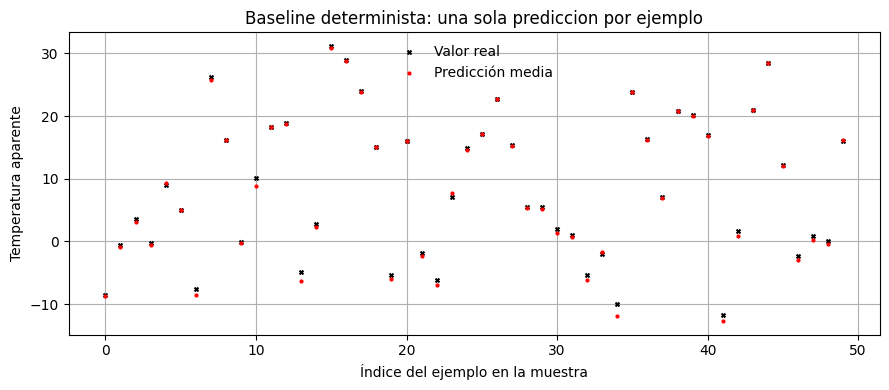

In [8]:
plot_prediction_summary(
    example_targets,
    deterministic_pred,
    title="Baseline determinista: una sola prediccion por ejemplo",
)


El baseline ya captura la relacion principal entre variables meteorologicas y temperatura aparente. Pero sigue faltando una estimacion de confianza. A partir de aca, todos los enfoques intentaran generar una **familia de predicciones** y no solo una.


## Parte 3

### Deep ensembles

En un deep ensemble entrenamos varias redes independientes y usamos la dispersion entre sus salidas como proxy de incerteza epistemica.

La intuicion es:

- distintas inicializaciones llevan a soluciones distintas;
- si usamos bootstrap, cada red ve una version algo distinta del dataset;
- la variabilidad entre miembros se interpreta como incertidumbre del modelo.


In [ ]:
def build_bootstrap_dataloader(train_dataloader, seed):
    X_train = train_dataloader.dataset.tensors[0].cpu().numpy()
    y_train = train_dataloader.dataset.tensors[1].cpu().numpy()
    rng = np.random.default_rng(seed)
    bootstrap_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    ds = TensorDataset(
        torch.from_numpy(X_train[bootstrap_idx]),
        torch.from_numpy(y_train[bootstrap_idx]),
    )
    return DataLoader(ds, batch_size=train_dataloader.batch_size, shuffle=True)


def ensemble_predictions(models, X):
    preds = []
    for model in models:
        preds.append(point_predictions(model, X))
    return np.stack(preds, axis=0)


ensemble_models = []
ensemble_size = 4

for member_idx in range(ensemble_size):
    set_seed(SEED + 100 + member_idx)
    member_loader = build_bootstrap_dataloader(train_dataloader, seed=SEED + 100 + member_idx)
    member = MLP(dropout_rate=0.0, hidden_units=hidden_units, activation="relu") # instancio nueva red para cada miembro del ensemble
    member = train_point_model(
        member,
        member_loader,
        test_dataloader,
        num_epochs=30,
        learning_rate=2e-3,
        print_every=None,
    )
    ensemble_models.append(member)


Test RMSE en unidades originales: 0.287


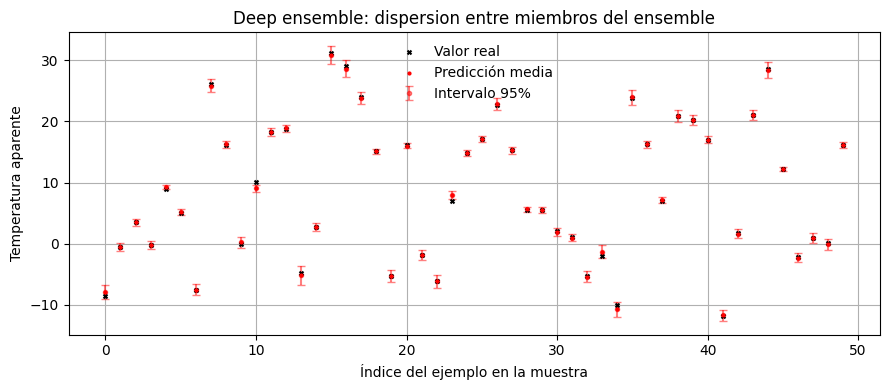

In [10]:
ensemble_test_predictions_std = ensemble_predictions(
    ensemble_models,
    test_dataloader.dataset.tensors[0],
)
ensemble_mean_test_std = ensemble_test_predictions_std.mean(axis=0)
ensemble_rmse = rmse_in_original_units(
    ensemble_mean_test_std,
    test_dataloader.dataset.tensors[1].squeeze(-1).cpu().numpy(),
)

ensemble_sample_predictions_std = ensemble_predictions(ensemble_models, example_inputs)
ensemble_sample_predictions = inverse_transform_targets(
    ensemble_sample_predictions_std.reshape(-1),
    weather["y_mean"],
    weather["y_std"],
).reshape(ensemble_sample_predictions_std.shape)

ensemble_mean, ensemble_std, ensemble_lower, ensemble_upper = summarize_samples(ensemble_sample_predictions)

print("Test RMSE en unidades originales:", round(float(ensemble_rmse), 3))
make_summary_table(
    example_targets,
    ensemble_mean,
    ensemble_std,
    ensemble_lower,
    ensemble_upper,
)

plot_prediction_summary(
    example_targets,
    ensemble_mean,
    ensemble_lower,
    ensemble_upper,
    title="Deep ensemble: dispersion entre miembros del ensemble",
)


Deep ensembles suelen ser un baseline muy fuerte en practica. Su principal costo es computacional: entrenamos varias redes completas.


## Parte 4

### Monte Carlo dropout

Ahora agregamos `dropout` a la red y lo dejamos activo tambien en inferencia. Repetir varias pasadas sobre la misma entrada produce distintas salidas, porque cada mascara de dropout induce una subred distinta.


In [11]:
def enable_dropout_only(model):
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


def mc_dropout_predictions(model, X, mc_samples=100):
    X = X.to(DEVICE)
    preds = []
    enable_dropout_only(model)
    with torch.no_grad():
        for _ in range(mc_samples):
            preds.append(model(X).squeeze(-1).cpu().numpy())
    return np.stack(preds, axis=0)


set_seed(SEED + 1)
dropout_model = MLP(dropout_rate=0.05, hidden_units=hidden_units, activation="relu")
dropout_model = train_point_model(
    dropout_model,
    train_dataloader,
    test_dataloader,
    num_epochs=40,
    learning_rate=2e-3,
    print_every=20,
)


Epoch   1/40 | train_rmse=0.984 | test_rmse=0.996
Epoch  20/40 | train_rmse=0.531 | test_rmse=0.526
Epoch  40/40 | train_rmse=0.674 | test_rmse=0.673


Test RMSE usando la media MC: 0.689


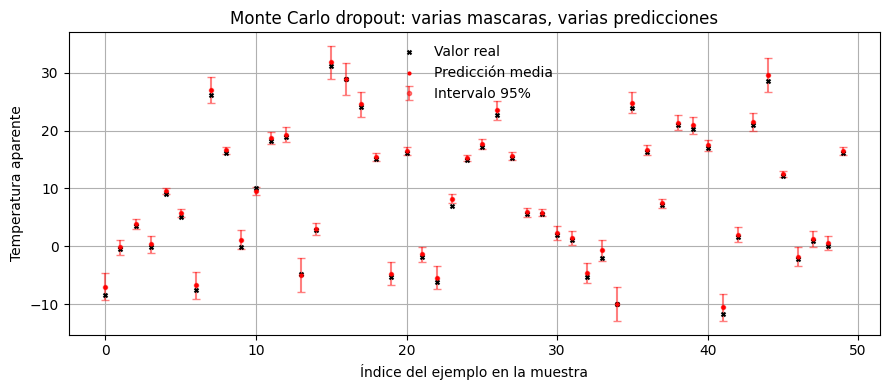

In [12]:
mc_test_predictions_std = mc_dropout_predictions(
    dropout_model,
    test_dataloader.dataset.tensors[0],
    mc_samples=50,
)
mc_mean_test_std = mc_test_predictions_std.mean(axis=0)
mc_rmse = rmse_in_original_units(
    mc_mean_test_std,
    test_dataloader.dataset.tensors[1].squeeze(-1).cpu().numpy(),
)

mc_sample_predictions_std = mc_dropout_predictions(dropout_model, example_inputs, mc_samples=100)
mc_sample_predictions = inverse_transform_targets(
    mc_sample_predictions_std.reshape(-1),
    weather["y_mean"],
    weather["y_std"],
).reshape(mc_sample_predictions_std.shape)

mc_mean, mc_std, mc_lower, mc_upper = summarize_samples(mc_sample_predictions)

print("Test RMSE usando la media MC:", round(float(mc_rmse), 3))
make_summary_table(
    example_targets,
    mc_mean,
    mc_std,
    mc_lower,
    mc_upper,
)

plot_prediction_summary(
    example_targets,
    mc_mean,
    mc_lower,
    mc_upper,
    title="Monte Carlo dropout: varias mascaras, varias predicciones",
)


MC dropout es mas barato que un ensemble completo y muchas veces ofrece una aproximacion razonable a la incerteza epistemica. Conceptualmente, sigue siendo una aproximacion indirecta.


## Parte 5

### Bayesian Neural Network con `bayesian-torch`

En una BNN ya no tratamos los pesos como valores fijos, sino como variables aleatorias. `bayesian-torch` implementa capas bayesianas reparameterized, y el entrenamiento combina:

- un termino de ajuste a datos;
- un termino `KL` que regulariza la posterior aproximada respecto de una prior.

Vamos a comparar una BNN entrenada con menos datos contra otra entrenada con todo el conjunto de entrenamiento.


In [13]:
class BayesianWeatherMLP(nn.Module):
    def __init__(
        self,
        prior_mean=0.0,
        prior_variance=1.0,
        posterior_mu_init=0.0,
        posterior_rho_init=-2.5,
    ):
        super().__init__()

        self.bn = nn.BatchNorm1d(NUM_FEATURES, eps=1e-3, momentum=0.99)
        self.fc1 = LinearReparameterization(
            in_features=NUM_FEATURES,
            out_features=hidden_units[0],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.fc2 = LinearReparameterization(
            in_features=hidden_units[0],
            out_features=hidden_units[1],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.out = nn.Linear(hidden_units[1], 1)

    def forward(self, x):
        kl_sum = 0.0
        x = self.bn(x)
        x, kl = self.fc1(x)
        kl_sum = kl_sum + kl
        x = F.relu(x)
        x, kl = self.fc2(x)
        kl_sum = kl_sum + kl
        x = F.relu(x)
        x = self.out(x)
        return x, kl_sum


def evaluate_bnn_rmse(model, dataloader, device=DEVICE, mc_samples=30):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            batch_preds = []
            for _ in range(mc_samples):
                pred, _ = model(X)
                batch_preds.append(pred.squeeze(-1).cpu().numpy())
            preds.append(np.mean(batch_preds, axis=0))
            targets.append(y.squeeze(-1).cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return rmse_in_original_units(preds, targets)


def train_bnn(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs=60,
    learning_rate=1e-3,
    kl_weight=0.02,
    print_every=20,
):
    model = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=learning_rate)
    mse_loss = nn.MSELoss()
    beta = kl_weight / len(train_dataloader.dataset)

    for epoch in range(1, num_epochs + 1):
        model.train()
        for X, y in train_dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            preds, kl = model(X)
            preds = preds.squeeze(-1)
            data_loss = mse_loss(preds, y.squeeze(-1))
            loss = data_loss + beta * kl
            loss.backward()
            optimizer.step()

        if print_every is not None and ((epoch % print_every == 0) or (epoch == 1) or (epoch == num_epochs)):
            train_rmse = evaluate_bnn_rmse(model, train_dataloader)
            test_rmse = evaluate_bnn_rmse(model, test_dataloader)
            print(
                f"Epoch {epoch:3d}/{num_epochs} | "
                f"train_rmse={train_rmse:.3f} | test_rmse={test_rmse:.3f}"
            )

    return model


def bnn_predictions(model, X, mc_samples=100):
    model.eval()
    X = X.to(DEVICE)
    preds = []
    with torch.no_grad():
        for _ in range(mc_samples):
            yhat, _ = model(X)
            preds.append(yhat.squeeze(-1).cpu().numpy())
    return np.stack(preds, axis=0)


In [14]:
weather_small = get_weather_dataloaders(
    train_size=TRAIN_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    dataset_size=0.40,
)

set_seed(SEED + 2)
bnn_small = BayesianWeatherMLP(posterior_rho_init=-2.0)
bnn_small = train_bnn(
    bnn_small,
    weather_small["train_loader"],
    weather_small["test_loader"],
    num_epochs=60,
    learning_rate=1e-3,
    kl_weight=0.02,
    print_every=20,
)

set_seed(SEED + 3)
bnn_full = BayesianWeatherMLP(posterior_rho_init=-2.5)
bnn_full = train_bnn(
    bnn_full,
    train_dataloader,
    test_dataloader,
    num_epochs=60,
    learning_rate=1e-3,
    kl_weight=0.02,
    print_every=20,
)


Epoch   1/60 | train_rmse=8.518 | test_rmse=8.570
Epoch  20/60 | train_rmse=0.893 | test_rmse=0.901
Epoch  40/60 | train_rmse=0.968 | test_rmse=0.992
Epoch  60/60 | train_rmse=1.007 | test_rmse=1.018
Epoch   1/60 | train_rmse=2.440 | test_rmse=2.442
Epoch  20/60 | train_rmse=1.226 | test_rmse=1.222
Epoch  40/60 | train_rmse=0.852 | test_rmse=0.837
Epoch  60/60 | train_rmse=0.595 | test_rmse=0.580


In [15]:
bnn_small_sample_predictions_std = bnn_predictions(bnn_small, example_inputs, mc_samples=100)
bnn_full_sample_predictions_std = bnn_predictions(bnn_full, example_inputs, mc_samples=100)

bnn_small_sample_predictions = inverse_transform_targets(
    bnn_small_sample_predictions_std.reshape(-1),
    weather_small["y_mean"],
    weather_small["y_std"],
).reshape(bnn_small_sample_predictions_std.shape)

bnn_full_sample_predictions = inverse_transform_targets(
    bnn_full_sample_predictions_std.reshape(-1),
    weather["y_mean"],
    weather["y_std"],
).reshape(bnn_full_sample_predictions_std.shape)

bnn_small_mean, bnn_small_std, _, _ = summarize_samples(bnn_small_sample_predictions)
bnn_full_mean, bnn_full_std, bnn_full_lower, bnn_full_upper = summarize_samples(bnn_full_sample_predictions)

bnn_comparison = pd.DataFrame(
    {
        "modelo": ["BNN con subset 40%", "BNN con train completo"],
        "rmse_test": [
            evaluate_bnn_rmse(bnn_small, weather_small["test_loader"]),
            evaluate_bnn_rmse(bnn_full, test_dataloader),
        ],
        "std_promedio_en_muestra": [
            bnn_small_std.mean(),
            bnn_full_std.mean(),
        ],
    }
).round(3)

bnn_comparison

,modelo,rmse_test,std_promedio_en_muestra
0,BNN con subset 40%,1.011,1.137
1,BNN con train completo,0.585,0.498


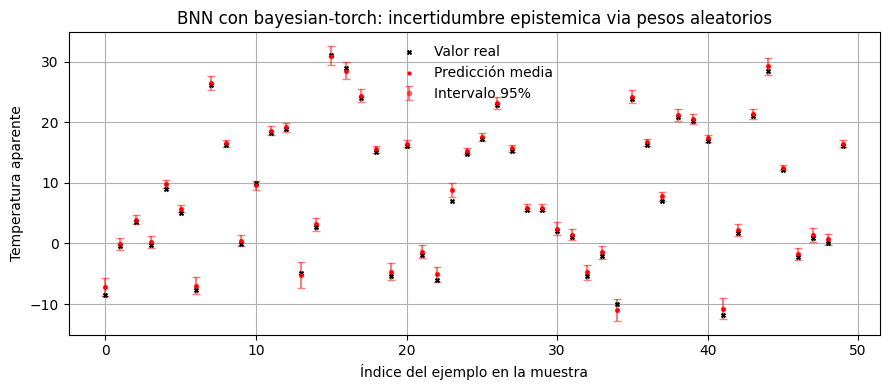

In [16]:
plot_prediction_summary(
    example_targets,
    bnn_full_mean,
    bnn_full_lower,
    bnn_full_upper,
    title="BNN con bayesian-torch: incertidumbre epistemica via pesos aleatorios",
)


La logica sigue siendo la misma: con menos datos, la posterior sobre pesos suele quedar menos concentrada y la variabilidad predictiva tiende a crecer.


## Parte 6

### BNN probabilistica

Hasta ahora la dispersion surgia solo de repetir pasadas con distintos pesos o distintas mascaras. En una BNN probabilistica, la red devuelve directamente una distribucion:

$$
y \mid x \sim \mathcal{N}(\mu(x), \sigma(x)).
$$

Aca la variacion entre distintas muestras de pesos aporta una componente epistemica, mientras que `sigma(x)` modela una componente aleatorica de la salida.


In [17]:
class ProbabilisticBayesianWeatherMLP(nn.Module):
    def __init__(
        self,
        prior_mean=0.0,
        prior_variance=1.0,
        posterior_mu_init=0.0,
        posterior_rho_init=-3.0,
        min_sigma=1e-3,
    ):
        super().__init__()
        self.min_sigma = min_sigma

        self.bn = nn.BatchNorm1d(NUM_FEATURES, eps=1e-3, momentum=0.99)
        self.fc1 = LinearReparameterization(
            in_features=NUM_FEATURES,
            out_features=hidden_units[0],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.fc2 = LinearReparameterization(
            in_features=hidden_units[0],
            out_features=hidden_units[1],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.param_head = nn.Linear(hidden_units[1], 2)

    def forward(self, x):
        kl_sum = 0.0
        x = self.bn(x)
        x, kl = self.fc1(x)
        kl_sum = kl_sum + kl
        x = F.relu(x)
        x, kl = self.fc2(x)
        kl_sum = kl_sum + kl
        x = F.relu(x)

        params = self.param_head(x)
        mu = params[:, 0]
        sigma = F.softplus(params[:, 1]) + self.min_sigma
        dist = Normal(loc=mu, scale=sigma)
        return dist, kl_sum


def evaluate_probabilistic_bnn_rmse(model, dataloader, device=DEVICE, mc_samples=30):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            batch_mu = []
            for _ in range(mc_samples):
                dist, _ = model(X)
                batch_mu.append(dist.loc.cpu().numpy())
            preds.append(np.mean(batch_mu, axis=0))
            targets.append(y.squeeze(-1).cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return rmse_in_original_units(preds, targets)


def train_probabilistic_bnn(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs=80,
    learning_rate=7e-4,
    kl_weight=0.005,
    print_every=20,
):
    model = model.to(DEVICE)
    optimizer = Adam(model.parameters(), lr=learning_rate)
    beta = kl_weight / len(train_dataloader.dataset)

    for epoch in range(1, num_epochs + 1):
        model.train()
        for X, y in train_dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            dist, kl = model(X)
            nll = -dist.log_prob(y.squeeze(-1)).mean()
            loss = nll + beta * kl
            loss.backward()
            optimizer.step()

        if print_every is not None and ((epoch % print_every == 0) or (epoch == 1) or (epoch == num_epochs)):
            train_rmse = evaluate_probabilistic_bnn_rmse(model, train_dataloader)
            test_rmse = evaluate_probabilistic_bnn_rmse(model, test_dataloader)
            print(
                f"Epoch {epoch:3d}/{num_epochs} | "
                f"train_rmse={train_rmse:.3f} | test_rmse={test_rmse:.3f}"
            )

    return model


def probabilistic_bnn_predictions(model, X, mc_samples=100):
    model.eval()
    X = X.to(DEVICE)

    mu_samples = []
    sigma_samples = []
    with torch.no_grad():
        for _ in range(mc_samples):
            dist, _ = model(X)
            mu_samples.append(dist.loc.cpu().numpy())
            sigma_samples.append(dist.scale.cpu().numpy())

    mu_samples = np.stack(mu_samples, axis=0)
    sigma_samples = np.stack(sigma_samples, axis=0)

    mu_samples_raw = inverse_transform_targets(
        mu_samples.reshape(-1),
        weather["y_mean"],
        weather["y_std"],
    ).reshape(mu_samples.shape)

    sigma_scale = weather["y_std"].cpu().numpy().reshape(-1)[0]
    sigma_samples_raw = sigma_samples * sigma_scale

    pred_mean = mu_samples_raw.mean(axis=0)
    epistemic_std = mu_samples_raw.std(axis=0)
    aleatoric_std = np.sqrt((sigma_samples_raw ** 2).mean(axis=0))
    total_std = np.sqrt(epistemic_std ** 2 + aleatoric_std ** 2)

    y_samples = mu_samples_raw + sigma_samples_raw * np.random.randn(*mu_samples_raw.shape)
    lower = np.quantile(y_samples, 0.025, axis=0)
    upper = np.quantile(y_samples, 0.975, axis=0)

    return {
        "pred_mean": pred_mean,
        "epistemic_std": epistemic_std,
        "aleatoric_std": aleatoric_std,
        "total_std": total_std,
        "lower": lower,
        "upper": upper,
    }


In [18]:
set_seed(SEED + 4)
probabilistic_bnn = ProbabilisticBayesianWeatherMLP(posterior_rho_init=-3.0)
probabilistic_bnn = train_probabilistic_bnn(
    probabilistic_bnn,
    train_dataloader,
    test_dataloader,
    num_epochs=80,
    learning_rate=7e-4,
    kl_weight=0.005,
    print_every=20,
)


Epoch   1/80 | train_rmse=2.669 | test_rmse=2.676
Epoch  20/80 | train_rmse=0.679 | test_rmse=0.673
Epoch  40/80 | train_rmse=0.467 | test_rmse=0.468
Epoch  60/80 | train_rmse=0.617 | test_rmse=0.618
Epoch  80/80 | train_rmse=0.569 | test_rmse=0.564


In [19]:
probabilistic_rmse = evaluate_probabilistic_bnn_rmse(probabilistic_bnn, test_dataloader)
probabilistic_summary = probabilistic_bnn_predictions(
    probabilistic_bnn,
    example_inputs,
    mc_samples=100,
)

probabilistic_table = make_summary_table(
    example_targets,
    probabilistic_summary["pred_mean"],
    probabilistic_summary["total_std"],
    probabilistic_summary["lower"],
    probabilistic_summary["upper"],
)
probabilistic_table["std_epistemica"] = probabilistic_summary["epistemic_std"]
probabilistic_table["std_aleatorica"] = probabilistic_summary["aleatoric_std"]
probabilistic_table = probabilistic_table.round(3)

print("Test RMSE usando la media predictiva:", round(float(probabilistic_rmse), 3))
probabilistic_table

Test RMSE usando la media predictiva: 0.569


,ejemplo,actual,pred_media,std,lim_inf_95,lim_sup_95,std_epistemica,std_aleatorica
0,0,-8.522000,-8.214000,1.557,-11.013,-4.654,0.566,1.450
1,1,-0.500000,-1.077000,0.962,-3.251,0.781,0.395,0.877
2,2,3.528000,3.054000,0.843,1.750,4.757,0.309,0.784
3,3,-0.206000,-0.715000,0.952,-2.661,1.138,0.406,0.861
4,4,9.011000,8.994000,0.735,7.103,10.179,0.258,0.688
5,5,5.044000,4.850000,0.768,3.438,6.104,0.263,0.721
6,6,-7.633000,-7.919000,1.375,-10.259,-5.140,0.531,1.269
7,7,26.156000,25.708000,1.431,22.410,28.343,0.465,1.353
8,8,16.183001,15.855000,0.641,14.643,17.098,0.233,0.597
9,9,-0.050000,-0.340000,1.084,-2.765,1.024,0.405,1.006


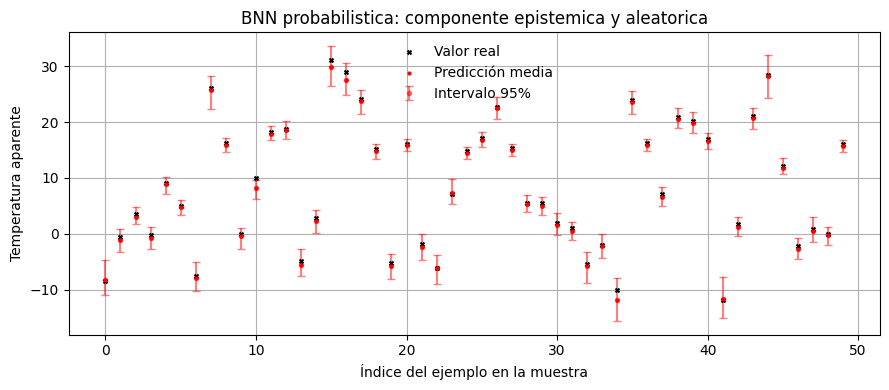

In [20]:
plot_prediction_summary(
    example_targets,
    probabilistic_summary["pred_mean"],
    probabilistic_summary["lower"],
    probabilistic_summary["upper"],
    title="BNN probabilistica: componente epistemica y aleatorica",
)


## Parte 7

### Comparacion global

Ahora resumimos todos los enfoques en una sola tabla. Como estamos trabajando en temperatura aparente, todas las metricas se reportan de nuevo en **unidades originales** y no en la escala estandarizada.


In [21]:
comparison_rows = [
    {
        "metodo": "Deterministica",
        "rmse_test": deterministic_rmse,
        "std_media_muestra": 0.0,
        "std_epistemica": 0.0,
        "std_aleatorica": 0.0,
    },
    {
        "metodo": "Deep ensemble",
        "rmse_test": ensemble_rmse,
        "std_media_muestra": ensemble_std.mean(),
        "std_epistemica": ensemble_std.mean(),
        "std_aleatorica": 0.0,
    },
    {
        "metodo": "MC dropout",
        "rmse_test": mc_rmse,
        "std_media_muestra": mc_std.mean(),
        "std_epistemica": mc_std.mean(),
        "std_aleatorica": 0.0,
    },
    {
        "metodo": "BNN",
        "rmse_test": evaluate_bnn_rmse(bnn_full, test_dataloader),
        "std_media_muestra": bnn_full_std.mean(),
        "std_epistemica": bnn_full_std.mean(),
        "std_aleatorica": 0.0,
    },
    {
        "metodo": "BNN probabilistica",
        "rmse_test": probabilistic_rmse,
        "std_media_muestra": probabilistic_summary["total_std"].mean(),
        "std_epistemica": probabilistic_summary["epistemic_std"].mean(),
        "std_aleatorica": probabilistic_summary["aleatoric_std"].mean(),
    },
]

comparison_df = pd.DataFrame(comparison_rows).round(3)
comparison_df


,metodo,rmse_test,std_media_muestra,std_epistemica,std_aleatorica
0,Deterministica,0.482,0.000,0.000,0.000
1,Deep ensemble,0.287,0.396,0.396,0.000
2,MC dropout,0.689,0.726,0.726,0.000
3,BNN,0.598,0.498,0.498,0.000
4,BNN probabilistica,0.569,1.052,0.383,0.978
